# A virtual fly, one reflex at a time

This notebook drives a **leaky integrate-and-fire model of the entire adult *Drosophila* brain**,
wired according to the FlyWire connectome (v783: 138,639 neurons, 54.5M synapses).
You pick neurons, make them fire, and watch what the rest of the brain does about it.

The circuit we use as a worked example is taste → **proboscis extension response (PER)**:
sugar on the labellum makes the fly stick out its proboscis to drink; bitter shuts that down.
The behavioural readout is a single motor neuron, **MN9**.

> Every result here is a *hypothesis generated from anatomy*. The connectome gives us who
> talks to whom and roughly how loudly; it does not give us synaptic strengths, intrinsic
> excitability, neuromodulation or plasticity. See the README's 'What this model does not know'.

## 1. Load the connectome

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from flybrain import Connectome, LIFNetwork, circuits

conn = Connectome()
conn

<Connectome 138,639 neurons, 15,091,983 edges, 54,492,920 synapses>

In [2]:
# The weight matrix is signed: excitatory (+) / inhibitory (-) from the
# FlyWire neurotransmitter prediction, magnitude = number of synapses.
print('shape        ', conn.W.shape)
print('edges        ', f'{conn.n_edges:,}')
print('inhibitory   ', f'{(conn.W.data < 0).mean():.1%} of connections')
print('median synapses per connection', int(np.median(np.abs(conn.W.data))))

shape         (138639, 138639)
edges         15,091,983
inhibitory    40.0% of connections
median synapses per connection 2


## 2. Find our neurons

21 labellar sugar-sensing gustatory receptor neurons (GRNs) on the right side, and MN9.
One sugar GRN was renumbered between the v630 and v783 releases and is dropped.

In [3]:
sugar  = conn.index(circuits.SUGAR_GRN)
bitter = conn.index(circuits.BITTER_GRN)
water  = conn.index(circuits.WATER_GRN)
mn9    = conn.index(circuits.MN9)

print('sugar GRNs in model:', len(sugar), '| dropped:', conn.missing(circuits.SUGAR_GRN))
print('MN9 model index:', mn9, '| direct inputs:', conn.W[:, mn9].nnz)

sugar GRNs in model: 20 | dropped: [720575940620900446]
MN9 model index: 138332 | direct inputs: 227


In [4]:
# Who does one sugar GRN talk to directly?
conn.downstream(circuits.SUGAR_GRN[0], top=8)

,root_id,signed_synapses
0,720575940625102692,23.0
1,720575940629888530,22.0
2,720575940637568838,21.0
3,720575940622695448,18.0
4,720575940641366517,15.0
5,720575940606866377,15.0
6,720575940632648612,14.0
7,720575940635179871,14.0


## 3. Make them fire

`run()` takes a dict of `{neurons: rate in Hz}` and imposes Poisson firing on them.
Everything else in the brain is free to respond. 500 ms of simulated time takes a few seconds.

In [5]:
net = LIFNetwork(conn, seed=1)

res = net.run({tuple(sugar.tolist()): 100.0}, t_run=0.5)
print(res)
print(f'MN9 fires at {res.rate(mn9):.0f} Hz')

<Result 331 neurons active, 1 trial(s) x 0.5s>
MN9 fires at 72 Hz


In [6]:
# The 15 most active neurons. Ones without a name are the model's prediction:
# interneurons the connectome says should light up when the fly tastes sugar.
res.table(min_rate=1.0, top=15, names=circuits.names(conn))

,name,root_id,rate_hz,std_hz
model_index,,,,
33909,,720575940618165019,148.0,0.0
100978,,720575940630868793,140.0,0.0
56459,,720575940622695448,136.0,0.0
95222,,720575940629778554,128.0,0.0
51107,sugar_GRN_8,720575940621754367,122.0,0.0
82138,,720575940627383685,122.0,0.0
28825,sugar_GRN_12,720575940616885538,116.0,0.0
95808,,720575940629888530,112.0,0.0
12494,sugar_GRN_21,720575940611875570,112.0,0.0


## 4. The control that makes it a result

A model that activates MN9 no matter what you poke is worthless. Bitter and Ir94e GRNs
are the same kind of cell in the same part of the brain — they should *not* drive PER.

In [7]:
for tag in ['sugar', 'bitter', 'water', 'ir94e']:
    idx = tuple(conn.index(circuits.SETS[tag]).tolist())
    r = net.run({idx: 100.0}, t_run=0.5)
    print(f'{tag:7s} at 100 Hz -> MN9 {r.rate(mn9):6.1f} Hz   ({len(r.active(1.0))} neurons active)')

sugar   at 100 Hz -> MN9   58.0 Hz   (347 neurons active)
bitter  at 100 Hz -> MN9    0.0 Hz   (50 neurons active)
water   at 100 Hz -> MN9    0.0 Hz   (81 neurons active)
ir94e   at 100 Hz -> MN9    0.0 Hz   (35 neurons active)


## 5. Bitter vetoes sugar

Now both at once. This is the interesting one: nothing in the code says bitter should
suppress anything. The suppression falls out of the wiring.

In [8]:
bitter_rates = [0, 25, 50, 75, 100, 150]
mn9_rates = []
for b in bitter_rates:
    r = net.run({tuple(sugar.tolist()): 100.0, tuple(bitter.tolist()): float(b)}, t_run=0.5)
    mn9_rates.append(r.rate(mn9))
    print(f'sugar 100 Hz + bitter {b:3d} Hz -> MN9 {mn9_rates[-1]:5.1f} Hz')

sugar 100 Hz + bitter   0 Hz -> MN9  76.0 Hz
sugar 100 Hz + bitter  25 Hz -> MN9  52.0 Hz
sugar 100 Hz + bitter  50 Hz -> MN9  44.0 Hz
sugar 100 Hz + bitter  75 Hz -> MN9  10.0 Hz
sugar 100 Hz + bitter 100 Hz -> MN9   0.0 Hz
sugar 100 Hz + bitter 150 Hz -> MN9   0.0 Hz


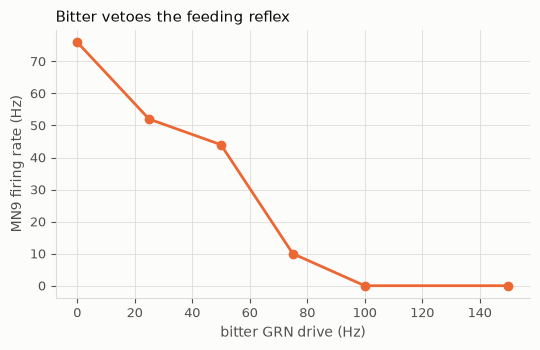

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 3.6), facecolor='#fcfcfb')
ax.plot(bitter_rates, mn9_rates, color='#eb6834', lw=2, marker='o', ms=6,
        solid_capstyle='round')
ax.set_facecolor('#fcfcfb')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
for s in ('left', 'bottom'): ax.spines[s].set_color('#dddcd8')
ax.grid(True, color='#dddcd8', lw=0.6); ax.set_axisbelow(True)
ax.tick_params(colors='#52514e', labelsize=9)
ax.set_xlabel('bitter GRN drive (Hz)', color='#52514e')
ax.set_ylabel('MN9 firing rate (Hz)', color='#52514e')
ax.set_title('Bitter vetoes the feeding reflex', color='#0b0b0b', fontsize=11, loc='left')
plt.tight_layout(); plt.show()

## 6. Knock a neuron out

`silence=` zeroes a neuron's output synapses — the model's version of an optogenetic
or genetic silencing experiment. Run each condition a few times (`n_trials`) because
the external drive is stochastic and single trials wobble by ~10 Hz.

Most of the neurons that light up under sugar turn out to be *brakes*: silencing them
makes MN9 fire harder. That asymmetry is a real prediction of the wiring, and it is the
kind of thing you would go and test in a fly.

In [10]:
base = net.run({tuple(sugar.tolist()): 100.0}, t_run=0.5, n_trials=3)
candidates = [i for i in base.active(20.0) if i not in set(sugar.tolist()) and i != mn9][:12]

print(f'baseline MN9: {base.rate(mn9):.0f} Hz\\n')
for i in candidates:
    r = net.run({tuple(sugar.tolist()): 100.0}, t_run=0.5, n_trials=3, silence=[i])
    delta = r.rate(mn9) - base.rate(mn9)
    role = 'gates it OPEN' if delta < -5 else ('holds it BACK' if delta > 5 else '')
    print(f'silence {conn.root_ids[i]}  ->  MN9 {r.rate(mn9):5.1f} Hz  ({delta:+5.1f})  {role}')

baseline MN9: 69 Hz\n
silence 720575940622695448  ->  MN9  85.3 Hz  (+16.0)  holds it BACK
silence 720575940618165019  ->  MN9  60.0 Hz  ( -9.3)  gates it OPEN
silence 720575940630868793  ->  MN9  64.0 Hz  ( -5.3)  gates it OPEN
silence 720575940627383685  ->  MN9  78.7 Hz  ( +9.3)  holds it BACK
silence 720575940629778554  ->  MN9  56.7 Hz  (-12.7)  gates it OPEN
silence 720575940629888530  ->  MN9  73.3 Hz  ( +4.0)  
silence 720575940640589171  ->  MN9 127.3 Hz  (+58.0)  holds it BACK
silence 720575940619973712  ->  MN9  67.3 Hz  ( -2.0)  
silence 720575940652580086  ->  MN9  79.3 Hz  (+10.0)  holds it BACK
silence 720575940626191306  ->  MN9  71.3 Hz  ( +2.0)  
silence 720575940632648612  ->  MN9  67.3 Hz  ( -2.0)  
silence 720575940628598121  ->  MN9  72.0 Hz  ( +2.7)  


## 7. Spike raster

What the response actually looks like in time: sugar GRNs driven, MN9 responding.

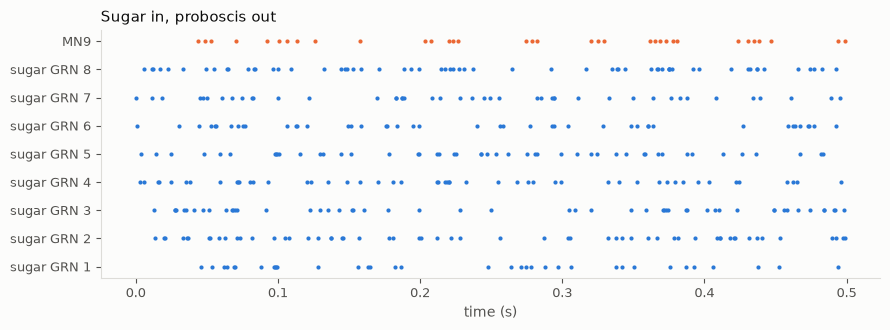

In [11]:
r = net.run({tuple(sugar.tolist()): 100.0}, t_run=0.5)
watch = list(sugar[:8]) + [mn9]
labels = [f'sugar GRN {i+1}' for i in range(8)] + ['MN9']

fig, ax = plt.subplots(figsize=(9, 3.4), facecolor='#fcfcfb')
ts, ns = r.raster(watch)
row = {int(n): k for k, n in enumerate(watch)}
colors = ['#2a78d6'] * 8 + ['#eb6834']
for k, n in enumerate(watch):
    m = ns == n
    ax.scatter(ts[m], np.full(m.sum(), k), s=9, color=colors[k], linewidths=0)
ax.set_facecolor('#fcfcfb')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
for s in ('left', 'bottom'): ax.spines[s].set_color('#dddcd8')
ax.set_yticks(range(len(watch))); ax.set_yticklabels(labels, fontsize=9)
ax.tick_params(colors='#52514e', labelsize=9)
ax.set_xlabel('time (s)', color='#52514e')
ax.set_title('Sugar in, proboscis out', color='#0b0b0b', fontsize=11, loc='left')
plt.tight_layout(); plt.show()

## Where to take it next

- **Other circuits.** Swap in any FlyWire root IDs — antennal-lobe olfactory neurons,
  T4/T5 motion detectors, descending neurons. Codex (codex.flywire.ai) is where you find them.
- **A body.** MN9's firing rate is a motor command. `FlyGym` / NeuroMechFly gives you a
  physical fly to send it to, which is how this stops being a circuit model and starts
  being a virtual animal.
- **Better dynamics.** The single free parameter `w_syn` is the obvious thing to fit,
  and per-cell-type time constants the obvious thing to add.